## Delivery Time vs Churn

*Churn = No activity for 30 days*
### Does slow delivery increase user churn?

In [1]:
from pyspark.sql import SparkSession

In [2]:
spark = (
    SparkSession.builder
    .appName("RapidKart Analytics")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark

In [3]:
events = spark.read.parquet(
"/content/drive/MyDrive/RapidKart/silver/events_sessionized")

orders = spark.read.parquet(
"/content/drive/MyDrive/RapidKart/bronze/orders")

user_summary = spark.read.parquet(
"/content/drive/MyDrive/RapidKart/gold/user_summary")

In [7]:
from pyspark.sql.functions import max as spark_max

last_activity = events.groupBy("user_id").agg(
    spark_max("event_time").alias("last_event_time")
)

dataset_end = events.select(max("event_time")).collect()[0][0]

In [5]:
last_activity.show()

+-------+-------------------+
|user_id|    last_event_time|
+-------+-------------------+
|     12|2024-03-04 20:47:00|
|     13|2024-01-14 08:33:00|
|     14|2024-03-27 01:24:00|
|     18|2024-03-08 09:12:00|
|     38|2024-03-27 09:29:00|
|     46|2024-02-07 11:19:00|
|     67|2024-03-29 23:40:00|
|     70|2024-01-18 21:32:00|
|     93|2024-03-27 00:50:00|
|    107|2024-03-27 08:52:00|
|    148|2024-02-19 10:30:00|
|    157|2024-03-27 08:13:00|
|    161|2024-02-09 00:08:00|
|    171|2024-03-22 10:22:00|
|    186|2024-01-17 10:34:00|
|    190|2024-03-28 07:56:00|
|    198|2024-01-22 16:33:00|
|    202|2024-03-22 08:10:00|
|    203|2024-02-06 10:36:00|
|    218|2024-03-06 10:26:00|
+-------+-------------------+
only showing top 20 rows


In [11]:
from pyspark.sql.functions import datediff, lit, when, col

churn_df = last_activity.withColumn(
    "days_inactive",
    datediff(lit(dataset_end), "last_event_time")).withColumn(
        "churned",when(col("days_inactive") > 30, 1).otherwise(0))

In [12]:
from pyspark.sql.functions import avg

delivery_per_user = orders.groupBy("user_id").agg(
    avg("delivery_time_minutes").alias("avg_delivery_time")
)

In [13]:
analysis_df = delivery_per_user.join(
    churn_df,
    "user_id",
    "inner"
)

In [17]:
analysis_df = analysis_df.withColumn(
    "delivery_bucket",
    when(col("avg_delivery_time") <= 15, "Fast") #constrainst
    .when(col("avg_delivery_time") <= 25, "Medium") #constraints
    .otherwise("Slow")
)

In [16]:
analysis_df.show(10)

+-------+-----------------+-------------------+-------------+-------+---------------+
|user_id|avg_delivery_time|    last_event_time|days_inactive|churned|delivery_bucket|
+-------+-----------------+-------------------+-------------+-------+---------------+
|     12|             16.0|2024-03-04 20:47:00|           27|      0|         Medium|
|     13|             13.0|2024-01-14 08:33:00|           77|      1|           Fast|
|     18|             15.5|2024-03-08 09:12:00|           23|      0|         Medium|
|     67|             11.0|2024-03-29 23:40:00|            2|      0|           Fast|
|    148|             21.0|2024-02-19 10:30:00|           41|      1|         Medium|
|    157|             18.0|2024-03-27 08:13:00|            4|      0|         Medium|
|    161|             16.0|2024-02-09 00:08:00|           51|      1|         Medium|
|    171|             23.5|2024-03-22 10:22:00|            9|      0|         Medium|
|    202|             16.0|2024-03-22 08:10:00|       

In [21]:
from pyspark.sql.functions import avg, count, round

churn_analysis = analysis_df.groupBy(
    "delivery_bucket"
).agg(
    round(avg("churned"),2).alias("churn_rate"),
    count("*").alias("users")
)

churn_analysis.show()

+---------------+----------+-----+
|delivery_bucket|churn_rate|users|
+---------------+----------+-----+
|           Fast|      0.41| 1809|
|           Slow|      0.46|  394|
|         Medium|      0.39| 3429|
+---------------+----------+-----+



In [22]:
churn_pd = churn_analysis.toPandas()

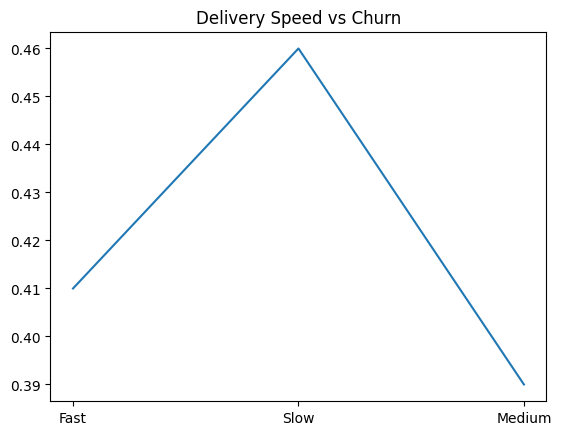

In [25]:
import matplotlib.pyplot as plt

plt.plot(churn_pd["delivery_bucket"], churn_pd["churn_rate"])
plt.title("Delivery Speed vs Churn")
plt.show()

### **Observation**

Users receiving slower deliveries (>25 minutes) exhibit the highest churn rate (46%), compared to medium delivery times (39%).

### **Interpretation**

Delivery delays negatively impact user retention. However, extremely fast deliveries do not necessarily guarantee better retention, suggesting that long-term engagement depends more on consistent service reliability than peak speed.

### **Business Recommendation**

- Prioritize reducing deliveries exceeding 25 minutes.

- Optimize dispatch allocation during peak demand.

- Focus on consistency rather than only ultra-fast delivery promises.

## Funnel Drop off Analysis

### Where do users drop in the purchase journey, and what should the product team fix?

In [26]:
funnel = spark.read.parquet(
"/content/drive/MyDrive/RapidKart/gold/funnel_metrics"
)

funnel.show(5)

+----------+--------+------------+-----------+--------+------+------------------+------------------+------------------+------------------+
|event_date|app_open|product_view|add_to_cart|checkout|orders|         view_rate|         cart_rate|     checkout_rate|     purchase_rate|
+----------+--------+------------+-----------+--------+------+------------------+------------------+------------------+------------------+
|2024-01-02|      15|          13|          7|       2|     1|0.8666666666666667|0.5384615384615384|0.2857142857142857|               0.5|
|2024-01-03|      25|          18|         15|      10|     7|              0.72|0.8333333333333334|0.6666666666666666|               0.7|
|2024-01-04|      47|          30|         23|      19|    11|0.6382978723404256|0.7666666666666667|0.8260869565217391|0.5789473684210527|
|2024-01-05|      83|          66|         48|      22|    17|0.7951807228915663|0.7272727272727273|0.4583333333333333|0.7727272727272727|
|2024-01-06|      99|      

In [27]:
from pyspark.sql.functions import sum as spark_sum

overall_funnel = funnel.select(
    spark_sum("app_open").alias("app_open"),
    spark_sum("product_view").alias("product_view"),
    spark_sum("add_to_cart").alias("add_to_cart"),
    spark_sum("checkout").alias("checkout"),
    spark_sum("orders").alias("orders")
)

overall_funnel.show()

+--------+------------+-----------+--------+------+
|app_open|product_view|add_to_cart|checkout|orders|
+--------+------------+-----------+--------+------+
|   47017|       35356|      23403|   13448|  9423|
+--------+------------+-----------+--------+------+



In [28]:
funnel_pd = overall_funnel.toPandas()
funnel_pd

,app_open,product_view,add_to_cart,checkout,orders
0,47017,35356,23403,13448,9423


In [41]:
import pandas as pd

app_open = funnel_pd["app_open"][0]
product_view = funnel_pd["product_view"][0]
add_to_cart = funnel_pd["add_to_cart"][0]
checkout = funnel_pd["checkout"][0]
orders = funnel_pd["orders"][0]

conversion = {
    "Open → View": product_view / app_open,
    "View → Cart": add_to_cart / product_view,
    "Cart → Checkout": checkout / add_to_cart,
    "Checkout → Purchase": orders / checkout
}

conversion_df = pd.DataFrame(list(conversion.items()), columns=['Step', 'Conversion Rate'])
conversion_df

,Step,Conversion Rate
0,Open → View,0.751983
1,View → Cart,0.661924
2,Cart → Checkout,0.574627
3,Checkout → Purchase,0.700699


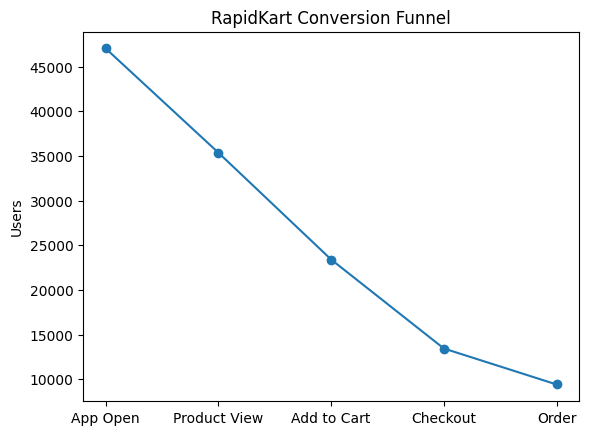

In [38]:
import matplotlib.pyplot as plt

steps = [
    "App Open",
    "Product View",
    "Add to Cart",
    "Checkout",
    "Order"
]

values = [app_open, product_view, add_to_cart, checkout, orders]

plt.plot(steps, values, marker="o")
plt.title("RapidKart Conversion Funnel")
plt.ylabel("Users")
plt.show()

In [42]:
drops = {
    "Open Loss": 1 - (product_view / app_open),
    "View Loss": 1 - (add_to_cart / product_view),
    "Cart Loss": 1 - (checkout / add_to_cart),
    "Checkout Loss": 1 - (orders / checkout)
}

drops = pd.DataFrame(list(drops.items()), columns=['Step', 'Drop Rate'])
drops

,Step,Drop Rate
0,Open Loss,0.248017
1,View Loss,0.338076
2,Cart Loss,0.425373
3,Checkout Loss,0.299301


### **Observation**

The largest conversion drop (42.5%) occurs between Add to Cart and Checkout, indicating users with strong purchase intent abandon before initiating payment.

### **Interpretation**

The issue likely arises from late-stage friction such as delivery costs, minimum order thresholds, or checkout complexity rather than product discovery or payment failure.

### **Business Recommendation**

- Display delivery fees earlier in browsing.

- Introduce cart nudges (“₹50 more for free delivery”).

- Simplify checkout entry.

- Offer limited-time cart reminders.

## Retention Cohort Analysis

### Do users continue using RapidKart after signup, and how quickly do we lose them?

In [43]:
cohort = spark.read.parquet(
"/content/drive/MyDrive/RapidKart/gold/retention_cohort"
)

cohort.show(5)

+-----------+-----------+-----+
|signup_date|week_number|count|
+-----------+-----------+-----+
| 2024-01-30|          4|  482|
| 2024-02-27|          2|  721|
| 2024-01-20|          2| 1079|
| 2024-01-12|          2| 1084|
| 2024-02-14|          3|  775|
+-----------+-----------+-----+
only showing top 5 rows


In [45]:
retention_pd = cohort.toPandas()


In [47]:
cohort_matrix = retention_pd.pivot(
    index="signup_date",
    columns="week_number",
    values="count"
)

cohort_size = cohort_matrix[0]

retention_matrix = cohort_matrix.divide(cohort_size, axis=0)

In [50]:
retention_matrix

week_number,0,1,2,3,4,5,6,7,8,9,10,11,12
signup_date,,,,,,,,,,,,,
2024-01-01,1.0,1.477000,0.997000,0.741000,0.478000,0.348000,0.240000,0.161000,0.143000,0.113000,0.036000,0.040000,0.018000
2024-01-02,1.0,1.293067,1.026261,0.675420,0.407563,0.221639,0.138655,0.056723,0.082983,0.057773,0.035714,NaN,NaN
2024-01-03,1.0,1.253119,0.704100,0.533868,0.336898,0.139037,0.086453,0.032086,0.013369,0.007130,0.009804,NaN,NaN
2024-01-04,1.0,1.139307,0.911898,0.634036,0.344127,0.346386,0.216867,0.148343,0.133283,0.133283,0.055723,0.064759,0.022590
2024-01-05,1.0,1.403333,1.151111,0.877778,0.436667,0.214444,0.147778,0.118889,0.100000,0.063333,0.068889,0.036667,0.011111
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03-26,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-03-27,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-03-28,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


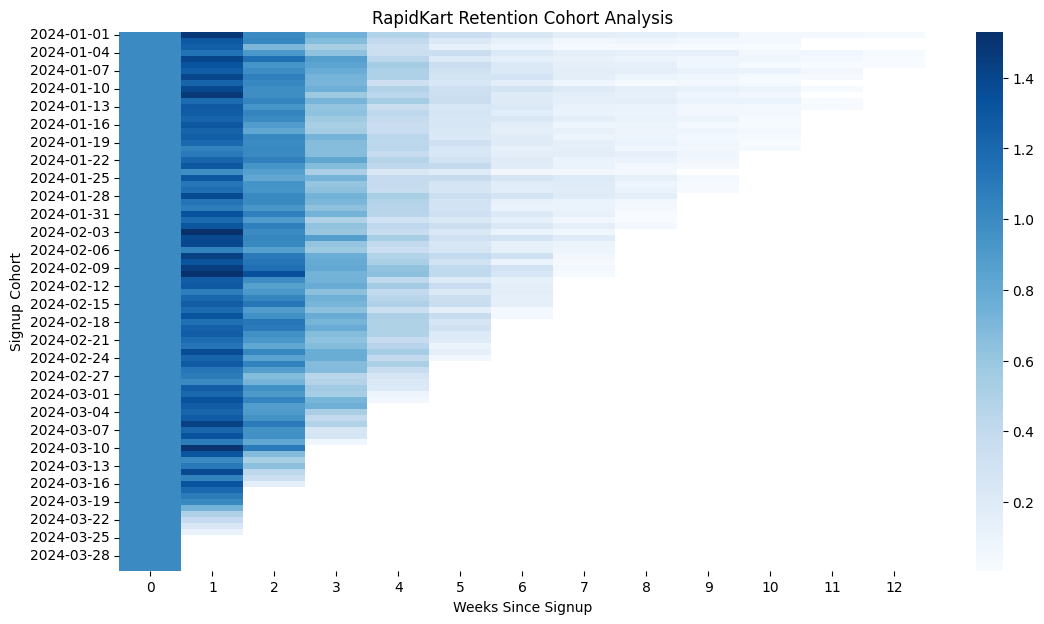

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(13,7))

sns.heatmap(
    retention_matrix,
    fmt=".2f",
    cmap="Blues"
)

plt.title("RapidKart Retention Cohort Analysis")
plt.ylabel("Signup Cohort")
plt.xlabel("Weeks Since Signup")

plt.show()

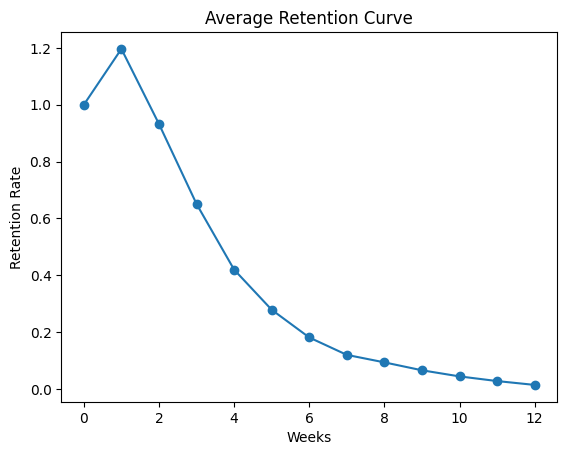

In [57]:
avg_retention = retention_matrix.mean()
avg_retention.plot(marker="o")
plt.title("Average Retention Curve")
plt.ylabel("Retention Rate")
plt.xlabel("Weeks")
plt.show()

### **Observation**

Retention declines sharply after the first few weeks, with the largest drop occurring between Week 2 and Week 4. Long-term retention stabilizes at very low levels beyond Week 8.

### **Interpretation**

Users are willing to try RapidKart initially but fail to develop consistent purchasing habits. This suggests onboarding and early repeat experience are critical drivers of long-term engagement.

### **Business Recommendation**

- Incentivize second and third orders within first 14 days.

- Introduce personalized reorder nudges.

- Improve early delivery consistency to reinforce trust.

## User Segementation

### How do different types of users behave, and who drives the business?

- orders >= 10 : power
- orders >= 3 : Regular
- orders >= 1 : Occasional
- Otherwise : Inactive

In [58]:
user_summary = spark.read.parquet(
"/content/drive/MyDrive/RapidKart/gold/user_summary"
)

orders = spark.read.parquet(
"/content/drive/MyDrive/RapidKart/bronze/orders"
)

In [60]:
from pyspark.sql.functions import sum as spark_sum

revenue_per_user = orders.groupBy("user_id").agg(
    spark_sum("order_value").alias("total_revenue")
)

analysis_df = user_summary.join(
    revenue_per_user,
    "user_id",
    "left"
).fillna(0)

In [61]:
segment_counts = analysis_df.groupBy("user_segment").count()
segment_counts.show()

+---------------+-----+
|   user_segment|count|
+---------------+-----+
|       Inactive| 3936|
|   Regular User|  896|
|Occasional User| 4736|
+---------------+-----+



In [63]:
from pyspark.sql.functions import avg

segment_revenue = analysis_df.groupBy("user_segment").agg(
    avg("total_revenue").alias("avg_revenue"),
    avg("total_orders").alias("avg_orders"),
    avg("total_sessions").alias("avg_sessions")
)

segment_revenue.show()

+---------------+------------------+------------------+------------------+
|   user_segment|       avg_revenue|        avg_orders|      avg_sessions|
+---------------+------------------+------------------+------------------+
|       Inactive|               0.0|               0.0|3.2131605691056913|
|   Regular User|2135.0616406250006|          3.515625|          9.890625|
|Occasional User| 792.9769320101345|1.3249577702702702|  5.38597972972973|
+---------------+------------------+------------------+------------------+



In [64]:
seg_pd = segment_revenue.toPandas()
seg_pd

,user_segment,avg_revenue,avg_orders,avg_sessions
0,Inactive,0.000000,0.000000,3.213161
1,Regular User,2135.061641,3.515625,9.890625
2,Occasional User,792.976932,1.324958,5.385980


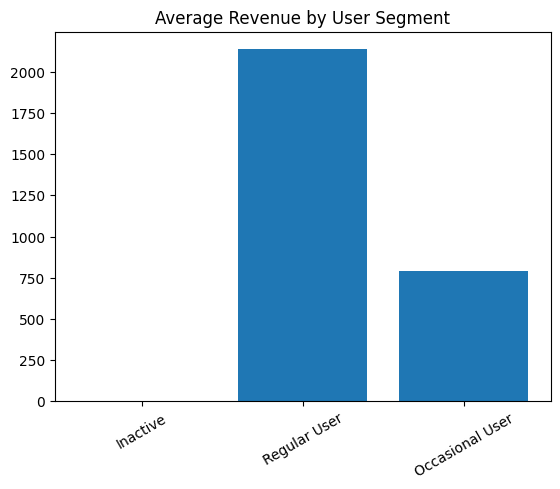

In [65]:
import matplotlib.pyplot as plt

plt.bar(seg_pd["user_segment"], seg_pd["avg_revenue"])
plt.title("Average Revenue by User Segment")
plt.xticks(rotation=30)
plt.show()

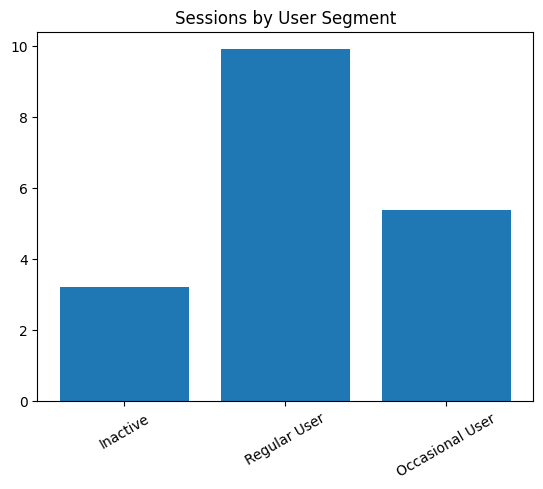

In [66]:
plt.bar(seg_pd["user_segment"], seg_pd["avg_sessions"])
plt.title("Sessions by User Segment")
plt.xticks(rotation=30)
plt.show()

### **Observation**

Regular users demonstrate significantly higher engagement and revenue contribution compared to occasional users, indicating repeat behavior is the primary driver of platform value.

### **Interpretation**

Most users interact with the platform but fail to transition into consistent repeat customers, suggesting gaps in habit formation and retention strategies.

### **Business Recommendation**

- Introduce loyalty incentives for regular users.

- Target occasional users with second-order promotions.

- Trigger personalized reminders after inactivity periods.

## Engagement → Conversion Relationship

### Engagement → Conversion Relationship

In [71]:
from pyspark.sql.functions import when, col, round

engagement_df = user_summary.withColumn(
    "engagement_level",
    when(col("total_sessions") <= 3, "Low")
    .when(col("total_sessions") <= 8, "Medium")
    .otherwise("High")
)

In [73]:
engagement_analysis = engagement_df.groupBy("engagement_level").agg(
    round(avg("total_orders"),2).alias("avg_orders"),
    round(avg("total_sessions"),2).alias("avg_sessions")
)

engagement_analysis.show()

+----------------+----------+------------+
|engagement_level|avg_orders|avg_sessions|
+----------------+----------+------------+
|             Low|      0.39|        1.92|
|            High|      2.24|       11.44|
|          Medium|      1.14|        5.62|
+----------------+----------+------------+



### **Insight**

Users with higher session engagement place significantly more orders, indicating engagement is a leading indicator of revenue growth.